In [1]:
import numpy as np
import matplotlib.pyplot as plt

# MAKING OWN SGD REGRESSOR CLASS

In [2]:
class sgdregressor:

    def __init__(self):
        self.w = None
        self.b = None

    def fit(self, x_train, y_train, epochs, alpha):

        self.w = np.zeros(x_train.shape[1])
        self.b = 0
        
        x_train = np.array(x_train)
        y_train = np.array(y_train)
        costs = []
        for i in range(epochs):

            for j in range(x_train.shape[0]):

                idx = np.random.randint(0, x_train.shape[0])

                x_i = x_train[idx]
                y_i = y_train[idx]

                y_hat = np.dot(x_i, self.w) + self.b

                error = y_i - y_hat

                dj_db = -2 * error
                dj_dw = -2 * error * x_i

                self.b = self.b - alpha * dj_db
                self.w = self.w - alpha * dj_dw

            y_pred = np.dot(x_train, self.w) + self.b

            cost = (1/2) * np.mean((y_train - y_pred) ** 2)
            costs.append(cost)

            print(f"Epoch {i+1}: cost = {cost}")

        epochs = list(range(1,epochs+1))
        plt.plot(epochs,costs,color='r')
        plt.xlabel("Epochs")
        plt.ylabel("Cost")
        plt.title("COST VS EPOCHS")
        plt.show()



    def predict(self, x_test):
        return np.dot(np.array(x_test), self.w) + self.b

Importing Dataset

In [3]:
import pandas as pd
df = pd.read_csv("C://Users//Acer//OneDrive//Desktop//Datasets//Student_Performance.csv")
df.sample(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
8177,1,59,Yes,7,4,31.0
7370,6,98,Yes,6,0,84.0
7757,9,75,No,9,0,74.0
4977,9,85,No,5,0,81.0
5139,7,49,No,5,3,37.0


In [4]:

x = df.drop(columns=['Performance Index','Extracurricular Activities','Hours Studied'])
y = df['Performance Index']


Train test split and scaling

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

LINEAR REGRESSION CLASS FOR COMPARISON

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
lr = LinearRegression()

lr.fit(x_train,y_train)

y_pred = lr.predict(x_test)

r2_score(y_test,y_pred)


0.8438120107931404

Fitting data in our own class
(This one is for smooth plot to visualize.)

Epoch 1: cost = 1253.407970500093
Epoch 2: cost = 917.1673702919752
Epoch 3: cost = 674.1969222665103
Epoch 4: cost = 497.5527940010492
Epoch 5: cost = 368.66979214968467
Epoch 6: cost = 275.18240180391746
Epoch 7: cost = 207.52255207364774
Epoch 8: cost = 158.6437285012504
Epoch 9: cost = 123.52651260451245
Epoch 10: cost = 97.75409302396787
Epoch 11: cost = 78.96499240674723
Epoch 12: cost = 65.33469996600321
Epoch 13: cost = 55.57574593184866
Epoch 14: cost = 48.44795095003001
Epoch 15: cost = 43.22066273390253
Epoch 16: cost = 39.444316916107354
Epoch 17: cost = 36.8073024792824
Epoch 18: cost = 34.79109535482191
Epoch 19: cost = 33.38113539012757
Epoch 20: cost = 32.37002832853019
Epoch 21: cost = 31.56732600711372
Epoch 22: cost = 31.036343811483558
Epoch 23: cost = 30.60371912541939
Epoch 24: cost = 30.324267171001388
Epoch 25: cost = 30.126264657102816
Epoch 26: cost = 29.96010333290237
Epoch 27: cost = 29.84397840181929
Epoch 28: cost = 29.76064460778804
Epoch 29: cost = 29.67

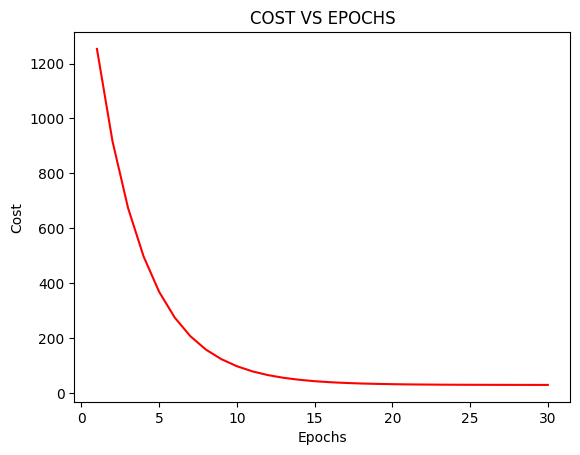

In [7]:
sgd = sgdregressor()
sgd.fit(x_train,y_train,alpha=0.00001,epochs=30)


Optimal hyperparameters

Epoch 1: cost = 101.03746188482715
Epoch 2: cost = 32.70345154597561
Epoch 3: cost = 29.66645094223335
Epoch 4: cost = 29.5269752890593
Epoch 5: cost = 29.52541759849294


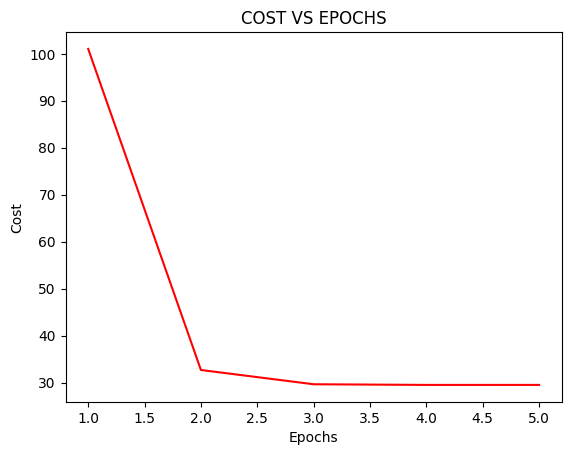

In [8]:
sgd = sgdregressor()
sgd.fit(x_train,y_train,alpha=0.0001,epochs=5)

Checking r2 score which is same as linear regression class

In [9]:
y_pred_sgd = sgd.predict(x_test)

r2_score(y_test,y_pred_sgd)

0.8437081909039291

Comparing with the sgd regressor class of sklearn 


In [10]:
from sklearn.linear_model import SGDRegressor

sgd2 = SGDRegressor(max_iter=5,learning_rate='constant',eta0=0.0001)
sgd2.fit(x_train,y_train)

c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",5
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [11]:
y_pred=sgd2.predict(x_test)
r2_score(y_test,y_pred)

0.8403085932245251